# Exercise 8.1
### Classification of magnetic phases using CNNs

Imagine a 2-dimensional lattice arrangement of $n \times n$ magnetic dipole moments (spins) that can be in one of two states ($+1$ or $−1$, Ising model).
With interactions between spins being short ranged, each spin interacts only with its four neighbors.
The probability to find a spin in one of the orientations is a function of temperature $T$ according to $p \sim e^{−a/T},\;a = \mathrm{const.}$).

At extremely low temperatures $T \rightarrow 0$, neighboring spins have a very low probability of different orientations, so that a uniform overall state (ferromagnetic state) is adopted, characterized by $+1$ or $−1$.
At very high temperatures $T \rightarrow \infty$, a paramagnetic phase with random spin alignment results, yielding $50\%$ of $+1$ and $0%$ of $−1$ orientations.
Below a critical temperature $0 < T < T_c$, stable ferromagnetic domains emerge, with both orientations being equally probable in the absence of an external magnetic field.
The spin-spin correlation function diverges at $T_c$, whereas the correlation decays for $T > T_c$.

The data for this task contain the $n \times n$ dipole orientations on the lattice for different temperatures $T$.
Classify the two magnetic phases (paramagnetic/ferromagnetic) using a convolutional neural network!

In [2]:
from tensorflow import keras
import numpy as np
callbacks = keras.callbacks
layers = keras.layers

from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D

### Load and prepare dataset
See https://doi.org/10.1038/nphys4035 for more information

In [3]:
import gdown
url = "https://drive.google.com/u/0/uc?export=download&confirm=HgGH&id=1Ihxt1hb3Kyv0IrjHlsYb9x9QY7l7n2Sl"
output = 'ising_data.npz'
#gdown.download(url, output, quiet=True)

f = np.load(output, allow_pickle=True)
n_train = 20000

x_train, x_test = f["C"][:n_train], f["C"][n_train:]
T_train, T_test = f["T"][:n_train], f["T"][n_train:]

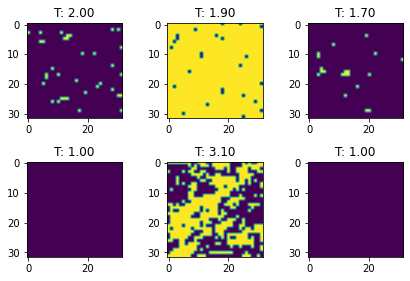

In [4]:
import matplotlib.pyplot as plt

for i,j in enumerate(np.random.choice(n_train, 6)):
    plt.subplot(2,3,i+1)
    image = x_train[j]
    plot = plt.imshow(image)
    plt.title("T: %.2f" % T_train[j])

plt.tight_layout()
plt.show()

Text(0, 0.5, 'frequency')

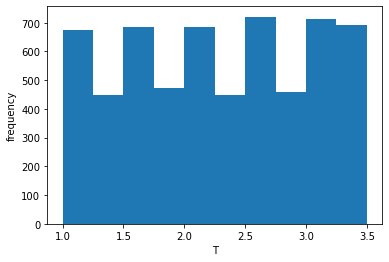

In [5]:
plt.hist(T_test)
plt.xlabel("T")
plt.ylabel("frequency")

#### Set up training data - define magnetic phases

In [6]:
Tc = 2.27
y_train, y_test = T_train > Tc, T_test > Tc

 ### Task

 - evaluate the test accuracy for a convolutional network,
 - plot the test accuracy vs. temperature.
 - compare to the results obtained using a fully-connected network (Exercise 7.1)

In [7]:
#start homework
print("shapes: T_train, T_test: "+str(T_train.shape)+str(T_test.shape))
print("shapes: x_train, x_test: "+str(x_train.shape)+str(x_test.shape))
print("shapes: y_train, y_test: "+str(y_train.shape)+str(y_test.shape))
print("A look at the data")
print("T for train: "+str(T_train[0:8]))
print("y for train (are T > Tc?): "+str(y_train[0:8]))

shapes: T_train, T_test: (20000,)(6000,)
shapes: x_train, x_test: (20000, 32, 32)(6000, 32, 32)
shapes: y_train, y_test: (20000,)(6000,)
A look at the data
T for train: [3.1 1.8 1.  3.  2.  2.8 3.  1.2]
y for train (are T > Tc?): [ True False False  True False  True  True False]


In [31]:
#build the net
#this time we use binary crossentropy (so, we do not need to one-hot encode)
imag_side=32
n_pixel=imag_side*imag_side #image size

model = Sequential()
model.add(layers.InputLayer(input_shape=(32, 32)))
model.add(layers.Reshape((32, 32,1)))
model.add(layers.Conv2D(16, (3, 3), activation='relu'))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='softmax'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(1)) 

"""
#example in https://www.tensorflow.org/tutorials/images/cnn

#with this net high accuracy for T>Tc, ~0.5 for T<Tc
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(imag_side, imag_side, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='softmax'))
model.add(layers.Dense(1)) 



"""


# Set loss function and optimiser algorithm
optim=keras.optimizers.Adam(learning_rate=0.001)
loss_model=keras.losses.BinaryCrossentropy()
model.compile(loss=loss_model,optimizer=optim,metrics=['accuracy'])

model.build((None, 1))
print (model.summary())

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_4 (Reshape)         (None, 32, 32, 1)         0         
                                                                 
 conv2d_10 (Conv2D)          (None, 30, 30, 16)        160       
                                                                 
 conv2d_11 (Conv2D)          (None, 28, 28, 32)        4640      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 flatten_5 (Flatten)         (None, 6272)              0         
                                                                 
 dense_10 (Dense)            (None, 32)                200736    
                                                      

In [32]:
epochs = 20
#save_period = 6  # after how many epochs the model should be saved?
batch_dim=64

history = model.fit(x_train, y_train, 
                    validation_data=(x_test, y_test),
                    epochs=epochs, batch_size=batch_dim)

#saving checkpoints
"""
chkpnt_saver = keras.callbacks.ModelCheckpoint("weights-{epoch:02d}.hdf5", save_weights_only=True, save_freq=save_period)

results = model.fit(
    x_train,
    y_train,
    batch_size=batch_dim,
    epochs=epochs,
    verbose=1,
    callbacks=[chkpnt_saver]
    )
"""

Epoch 1/20
313/313 [==============================] - 9s 24ms/step - loss: 0.3597 - accuracy: 0.8277 - val_loss: 0.1827 - val_accuracy: 0.9842
Epoch 2/20
313/313 [==============================] - 6s 21ms/step - loss: 0.1765 - accuracy: 0.9257 - val_loss: 0.1036 - val_accuracy: 0.9842
Epoch 3/20
313/313 [==============================] - 6s 21ms/step - loss: 0.1321 - accuracy: 0.9487 - val_loss: 0.0474 - val_accuracy: 0.9842
Epoch 4/20
313/313 [==============================] - 7s 21ms/step - loss: 0.1167 - accuracy: 0.9711 - val_loss: 0.0529 - val_accuracy: 0.9845
Epoch 5/20
313/313 [==============================] - 6s 20ms/step - loss: 0.2083 - accuracy: 0.9491 - val_loss: 0.0622 - val_accuracy: 0.9820
Epoch 6/20
313/313 [==============================] - 6s 20ms/step - loss: 0.0997 - accuracy: 0.9791 - val_loss: 0.0723 - val_accuracy: 0.9823
Epoch 7/20
313/313 [==============================] - 7s 21ms/step - loss: 0.1217 - accuracy: 0.9750 - val_loss: 0.0649 - val_accuracy: 0.9838

'\nchkpnt_saver = keras.callbacks.ModelCheckpoint("weights-{epoch:02d}.hdf5", save_weights_only=True, save_freq=save_period)\n\nresults = model.fit(\n    x_train,\n    y_train,\n    batch_size=batch_dim,\n    epochs=epochs,\n    verbose=1,\n    callbacks=[chkpnt_saver]\n    )\n'

In [33]:
# The history object returned by the model training above 
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]
acc=history.history["accuracy"]
val_acc=history.history['val_accuracy']

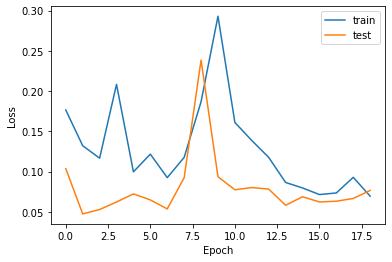

In [34]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

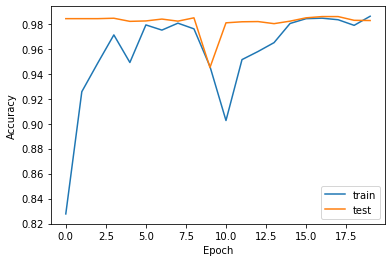

In [35]:
#plot accuracy over time

plt.plot(acc,label="train")
plt.plot(val_acc,label="test")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [36]:
a = model.evaluate(x_test, y_test, verbose=0)
preds = model.predict(x_test).round().squeeze()

#acc_array=np.array(preds == y_test).astype(float)
print(preds)
print(y_test)
acc = (preds == y_test).astype(float)
print(acc)

188/188 [==============================] - 1s 3ms/step
[-0.  0.  1. ... -0.  1.  1.]
[False False  True ... False  True  True]
[1. 1. 1. ... 1. 1. 1.]


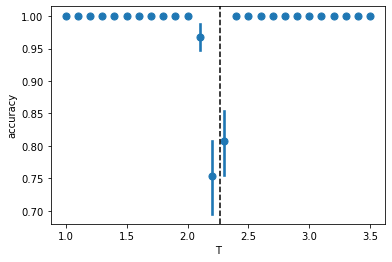

In [37]:
import seaborn as sns

ax = sns.regplot(x=T_test, y=acc, x_estimator= np.mean, fit_reg=False)
ax.set_ylabel("accuracy")
ax.set_xlabel("T")
plt.axvline(x=Tc, color='k', linestyle='--', label='Tc')

